# Example: Running a model

The following notebook provides instruction and code on how to use and run models using the garisom-tools package.

In [ ]:
from garisom_tools import SperryModel, PotkayModel
from garisom_tools.config import MetricConfig

import os
import pandas as pd
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

## Sperry Model

### Pre-requisites

To use the model, one must first clone the [GARISOM](https://github.com/colinpannikkat/garisom) package and compile it. Follow the directions in the repository to
1. Setup and compile the model
2. Use the file builder to setup the necessary dataset, parameter, and configuration files (this is required since the configuration file requires absolute file paths)

Example files are included in `./files`.

In [52]:
# Directory links needed
model_dir = "./garisom/02_program_code/"
param_directory = "./DBG/"

In [53]:
# Set population (corresponds to line in parameters.csv file)
population = 1

In [ ]:
# Function to get parameter and configuration files
def get_parameter_and_configuration_files(base_dir: str) -> tuple[str, pd.DataFrame]:
    return os.path.abspath(os.path.join(base_dir, "configuration.csv")), \
        pd.read_csv(os.path.join(base_dir, "parameters.csv"))

model_config, params = get_parameter_and_configuration_files(param_directory)

In [55]:
# Fetch the ground truth csv file for population
def get_ground_truth(population: int):
    ground_dir = "./files/ground"
    match population:
        case 1:
            ground = pd.read_csv(os.path.abspath(f"{ground_dir}/ccr_hourly_data.csv"))
        case 2:
            ground = pd.read_csv(os.path.abspath(f"{ground_dir}/jla_hourly_data.csv"))
        case 3:
            ground = pd.read_csv(os.path.abspath(f"{ground_dir}/nrv_hourly_data.csv"))
        case 4:
            ground = pd.read_csv(os.path.abspath(f"{ground_dir}/tsz_hourly_data.csv"))
        case _:
            raise Exception("Incorrect POP_NUM!")

    return ground
ground = get_ground_truth(population)

In [56]:
# Necessary start and date datetime instances for evaluation
start_date = datetime(2023, 7, 20)
end_date = datetime(2023, 8, 24)

In [ ]:
# Create a metric config (this is how we define what outputs to evaluate and with what metrics)
metric_config_dict = {
    'params': ['GW.a', 'GW.b', 'leaftemp'],  # 'params' can include suffixes (e.g., 'output_var.a', 'output_var.b') for multiple metrics on same output
    'metrics': ['rmse', 'mape', 'nnse'],  # Metric names must be supported by the Metric.from_name() method, see garisom_tools/utils/metric.py for a full list
    'modes': ['min', 'min', 'max']  # either 'min' or 'max' (either minimize or maximize error, used in optimization)
}
metric_config = MetricConfig.from_dict(metric_config_dict)

### Running

In [ ]:
model = SperryModel()  # create model

In [ ]:
output = model.run(
    params=params,
    config_file=model_config,
    population=population,
    model_dir=model_dir,
    X=None,  # Can pass parameters to overwrite default parameter file
    verbose=False  # can print out model output if needed for debugging
)

### Evaluation

In [59]:
eval_results = model.evaluate_model(
    output=output,
    ground=ground,
    metric_config=metric_config,
    start_date=start_date,
    end_date=end_date,
)
eval_results

{'GW.a': 115.63859211348088,
 'GW.b': 0.3993295510771159,
 'leaftemp': 0.8414411049420776}

### Running Model in Parallel

It can be helpful to run the model multiple times across multiple different parameter sets in order to save computation time.

Say the model takes ~15 seconds to run for your dataset, if you wanted to run the model across 1000 different parameter inputs it would then take ~4.17 hours.

With parallel execution, if running on a computer with 30 CPU cores, you can then run 30 parameter inputs simultaneously, equaling ~33 batches. This decreases the execution time to ~8.33 minutes.


In [60]:
# Produce different sets of parameters, varying LAI from 1 to 5.
X = [
    {'i_leafAreaIndex': float(lai)}
    for lai in np.arange(start=1, stop=5, step=0.5)
]

In [ ]:
# Run with 8 parameter sets
parallel_output = model.run_parallel(
    params=params,
    config_file=model_config,
    population=population,
    model_dir=model_dir,
    workers=4,  # number of concurrent worker threads, limited by # of CPU cores
    X=X  # overwrites default parameters
)

100%|██████████| 8/8 [00:10<00:00,  1.31s/it]


In [74]:
len(parallel_output)  # Different output dataframes produced, corresponds to each parameter set passed in order

8

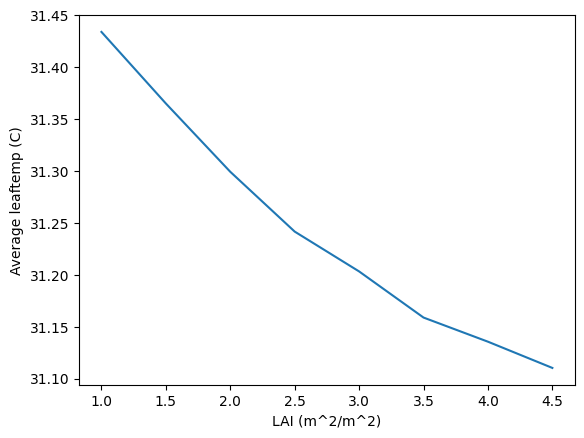

In [ ]:
# Can look at trends of outputs w.r.t certain input variables
lai_values = [d['i_leafAreaIndex'] for d in X]
plt.plot(lai_values, [o['leaftemp'].mean() for o in parallel_output if o is not None])
plt.xlabel("LAI (m^2/m^2)")
plt.ylabel("Average leaftemp (C)")
plt.show()

## Potkay Model

To be added...